<a href="https://colab.research.google.com/github/mhmd1243/data/blob/main/real_estate_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

from sklearn.preprocessing import (MinMaxScaler,OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (r2_score,root_mean_squared_error,accuracy_score)

import warnings
warnings.filterwarnings('ignore')
sns.color_palette("rocket")
sns.set_style('dark')
sns.set_context('notebook')
plt.style.use('bmh')

In [ ]:
df=pd.read_csv("/content/egypt_real_estate_listings.csv",cache_dates=True)

In [ ]:
df.sample(5)

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
6628,https://www.propertyfinder.eg/en/plp/buy/apart...,"8,775,200","Stone Residence, Fifth Settlement\n220-square-...","Stone Residence, 5th Settlement Compounds, The...",Apartment,"2,368 sqft / 220 sqm",4,3,31-Aug-25,Installments,"500,000 EGP"
9656,https://www.propertyfinder.eg/en/plp/buy/apart...,"6,300,000","Apartment for Sale in Al Rehab – 99 sqm, Owner...","North Rehab, New Cairo City, Cairo",Apartment,"1,066 sqft / 99 sqm",2+ Maid,1,2-Sep-25,Cash,NaN
19528,https://www.propertyfinder.eg/en/plp/buy/penth...,"19,430,181","-Pearl Penthouse – June, SODIC Ras El Hekma fo...","June, Ras Al Hekma, North Coast",Penthouse,"2,594 sqft / 241 sqm",4+ Maid,5,30-Aug-25,Cash,NaN
10054,https://www.propertyfinder.eg/en/plp/buy/apart...,"7,200,000",Apartment for sale with a prime location in Ne...,"Stone Residence, 5th Settlement Compounds, The...",Apartment,"2,368 sqft / 220 sqm",3,3,27-Aug-25,Cash,NaN
8254,https://www.propertyfinder.eg/en/plp/buy/apart...,"6,500,000",Great Opportunity to Live in the Heart of New ...,"Retaj, South Investors Area, New Cairo City, C...",Apartment,"1,410 sqft / 131 sqm",2,2,2-Sep-25,Cash,NaN


In [ ]:
df.shape

(19924, 11)

In [ ]:
df.describe()

,url,price,description,location,type,size,bedrooms,bathrooms,available_from,payment_method,down_payment
count,19924,19385,19846,19833,19847,19847,19780,19784,19261,19383,5445
unique,19924,4286,18130,1535,17,683,18,9,353,2,2030
top,https://www.propertyfinder.eg/en/plp/buy/chale...,"10,000,000",Please Note Before Reading:\nThis is one of ma...,"Marassi, Sidi Abdel Rahman, North Coast",Apartment,"1,507 sqft / 140 sqm",3,3,1-Sep-25,Cash,"100,000 EGP"
freq,1,307,72,433,8355,432,4959,6610,3254,15521,203


In [ ]:
df.isna().sum()

,0
url,0
price,539
description,78
location,91
type,77
size,77
bedrooms,144
bathrooms,140
available_from,663
payment_method,541


In [ ]:
df = df[df['price'].notna()]

In [ ]:
df=df.drop(['url','description','location','available_from','down_payment'],axis=1)

In [ ]:
df['bedrooms'].unique()

array(['1+ Maid', '4', '2', '3', '7', '5+ Maid', '3+ Maid', '2+ Maid',
       '1', '4+ Maid', '7+ Maid', 'studio', '5', '6+ Maid', nan,
       'studio+ Maid', '7++ Maid', '7+', '6'], dtype=object)

In [ ]:
bed_room_correction={
    '1+ Maid':2,
    '5+ Maid':6,
    '3+ Maid':4,
    '2+ Maid':3,
    '4+ Maid':5,
    '7+ Maid':8,
    'studio':1,
    '6+ Maid':7,
    'studio+ Maid':2,
    '7++ Maid':8,
    '7+':7,
    '1':1, '2':2, '3':3, '4':4, '5':5, '6':6, '7':7
}
df['bedrooms']=df['bedrooms'].map(bed_room_correction)


In [ ]:
df['bathrooms'].unique()

array(['1', '4', '2', '7', '5', '3', '6', '7+', nan, 'none'], dtype=object)

In [ ]:
df['bathrooms']=df['bathrooms'].replace('7+',7,regex=False)
df['bathrooms']=df['bathrooms'].replace('none',1,regex=False)
df['bathrooms'] = df['bathrooms'].astype(float)

In [ ]:
df['price']=df['price'].str.replace(',','',regex=False)

In [ ]:
df['size'] = (
    df['size']
    .str.split('/')
    .str[1]
    .str.replace('sqm', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
).astype(int)

In [ ]:
df.sample(10)

,price,type,size,bedrooms,bathrooms,payment_method
15315,26500000,Apartment,200,4.0,3.0,Cash
5821,39000000,Twin House,310,4.0,3.0,Installments
8754,7200000,Chalet,120,3.0,3.0,Cash
8737,17500000,Apartment,197,3.0,3.0,Cash
11361,6571000,Chalet,134,2.0,2.0,Cash
582,5050000,Apartment,67,1.0,1.0,Installments
8231,41000000,Townhouse,463,6.0,5.0,Cash
10177,8500000,Apartment,143,2.0,3.0,Cash
19617,6100000,Chalet,80,3.0,2.0,Cash
7314,2990000,Apartment,136,4.0,3.0,Cash


In [ ]:
df.isna().sum()

,0
price,0
type,0
size,0
bedrooms,63
bathrooms,59
payment_method,2


In [ ]:
df.duplicated().sum()

np.int64(2076)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.sample(5)

,price,type,size,bedrooms,bathrooms,payment_method
17879,45000000,Villa,244,4.0,3.0,Cash
9177,16000000,Apartment,133,2.0,2.0,Cash
9127,27000000,Townhouse,270,5.0,5.0,Cash
6535,13732087,Duplex,228,2.0,3.0,Installments
11919,1699000,Chalet,35,1.0,1.0,Cash


In [ ]:
numerical_imputer=SimpleImputer(strategy='mean')
df_num_col=['bedrooms','bathrooms']
for col in df_num_col:
    df[col]=numerical_imputer.fit_transform(df[[col]])
df['payment_method'].ffill(inplace=True)

In [ ]:
df['price']=df['price'].astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17309 entries, 0 to 19922
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           17309 non-null  float64
 1   type            17309 non-null  object 
 2   size            17309 non-null  int64  
 3   bedrooms        17309 non-null  float64
 4   bathrooms       17309 non-null  float64
 5   payment_method  17309 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 946.6+ KB


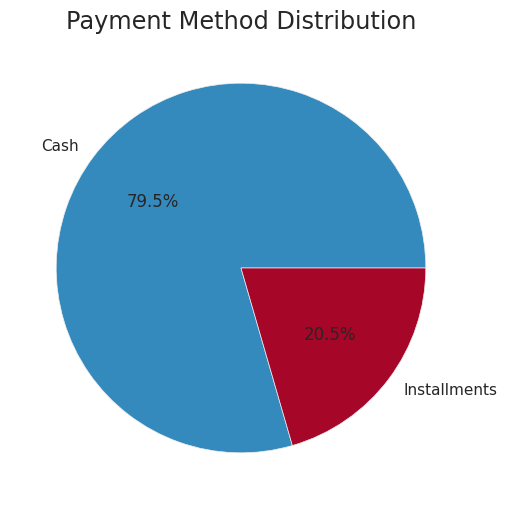

In [ ]:
sizes = df['payment_method'].value_counts()
labels = sizes.index

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

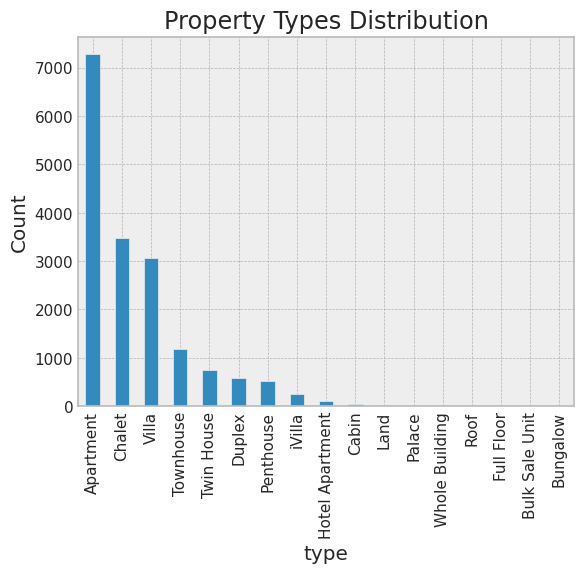

In [ ]:
df['type'].value_counts().plot(kind='bar')
plt.ylabel("Count")
plt.title("Property Types Distribution")
plt.show()

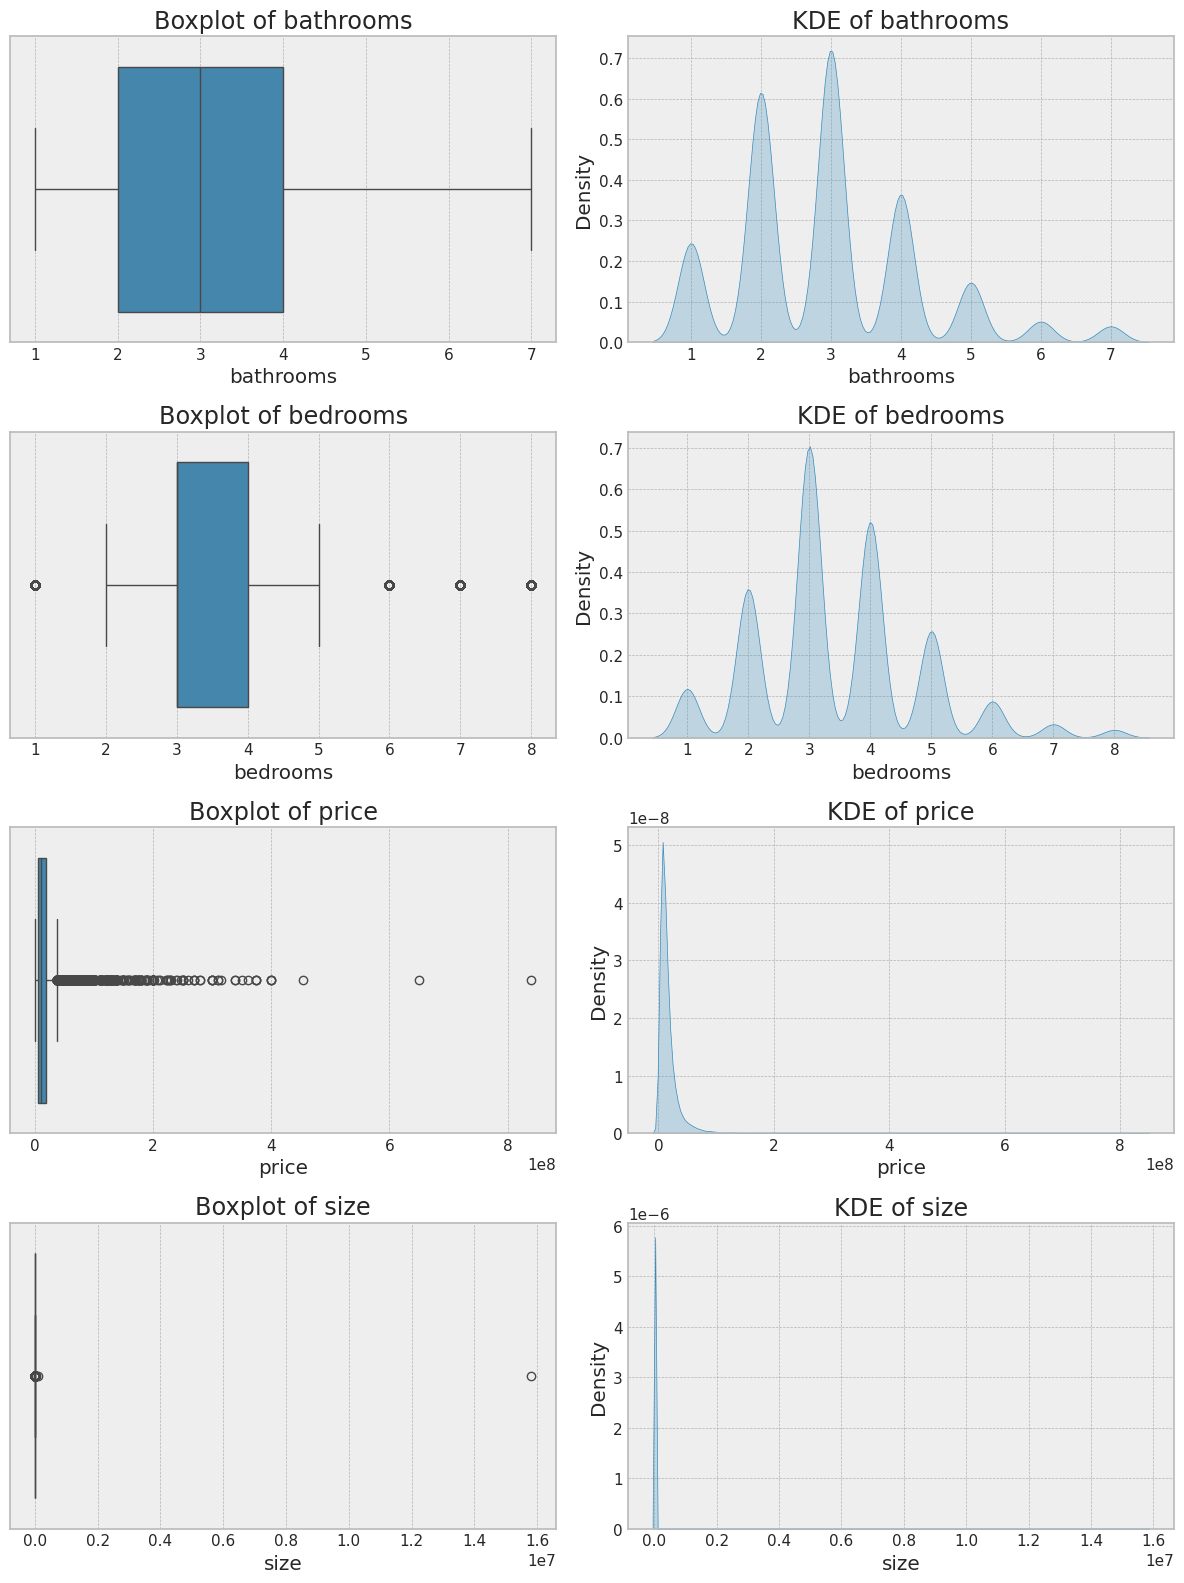

In [ ]:
numeric_col = ['bathrooms','bedrooms','price','size']
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for i, col in enumerate(numeric_col):
    sns.boxplot(x=df[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'Boxplot of {col}')
    sns.kdeplot(df[col], fill=True, ax=axes[i, 1])
    axes[i, 1].set_title(f'KDE of {col}')
plt.tight_layout()
plt.show()

In [ ]:
df = df[df['price'] < df['price'].quantile(0.99)]
df = df[df['size'] < df['size'].quantile(0.99)]
df['bath_to_bed']=df['bathrooms']/df['bedrooms']
df['price_per_meter']=df['price']/df['size']

In [ ]:
y = df['price']
X=df.drop(['price'],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [ ]:
categorical_cols = ['payment_method','type']
numerical_cols = ['bathrooms','bedrooms','size']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', MinMaxScaler(), numerical_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

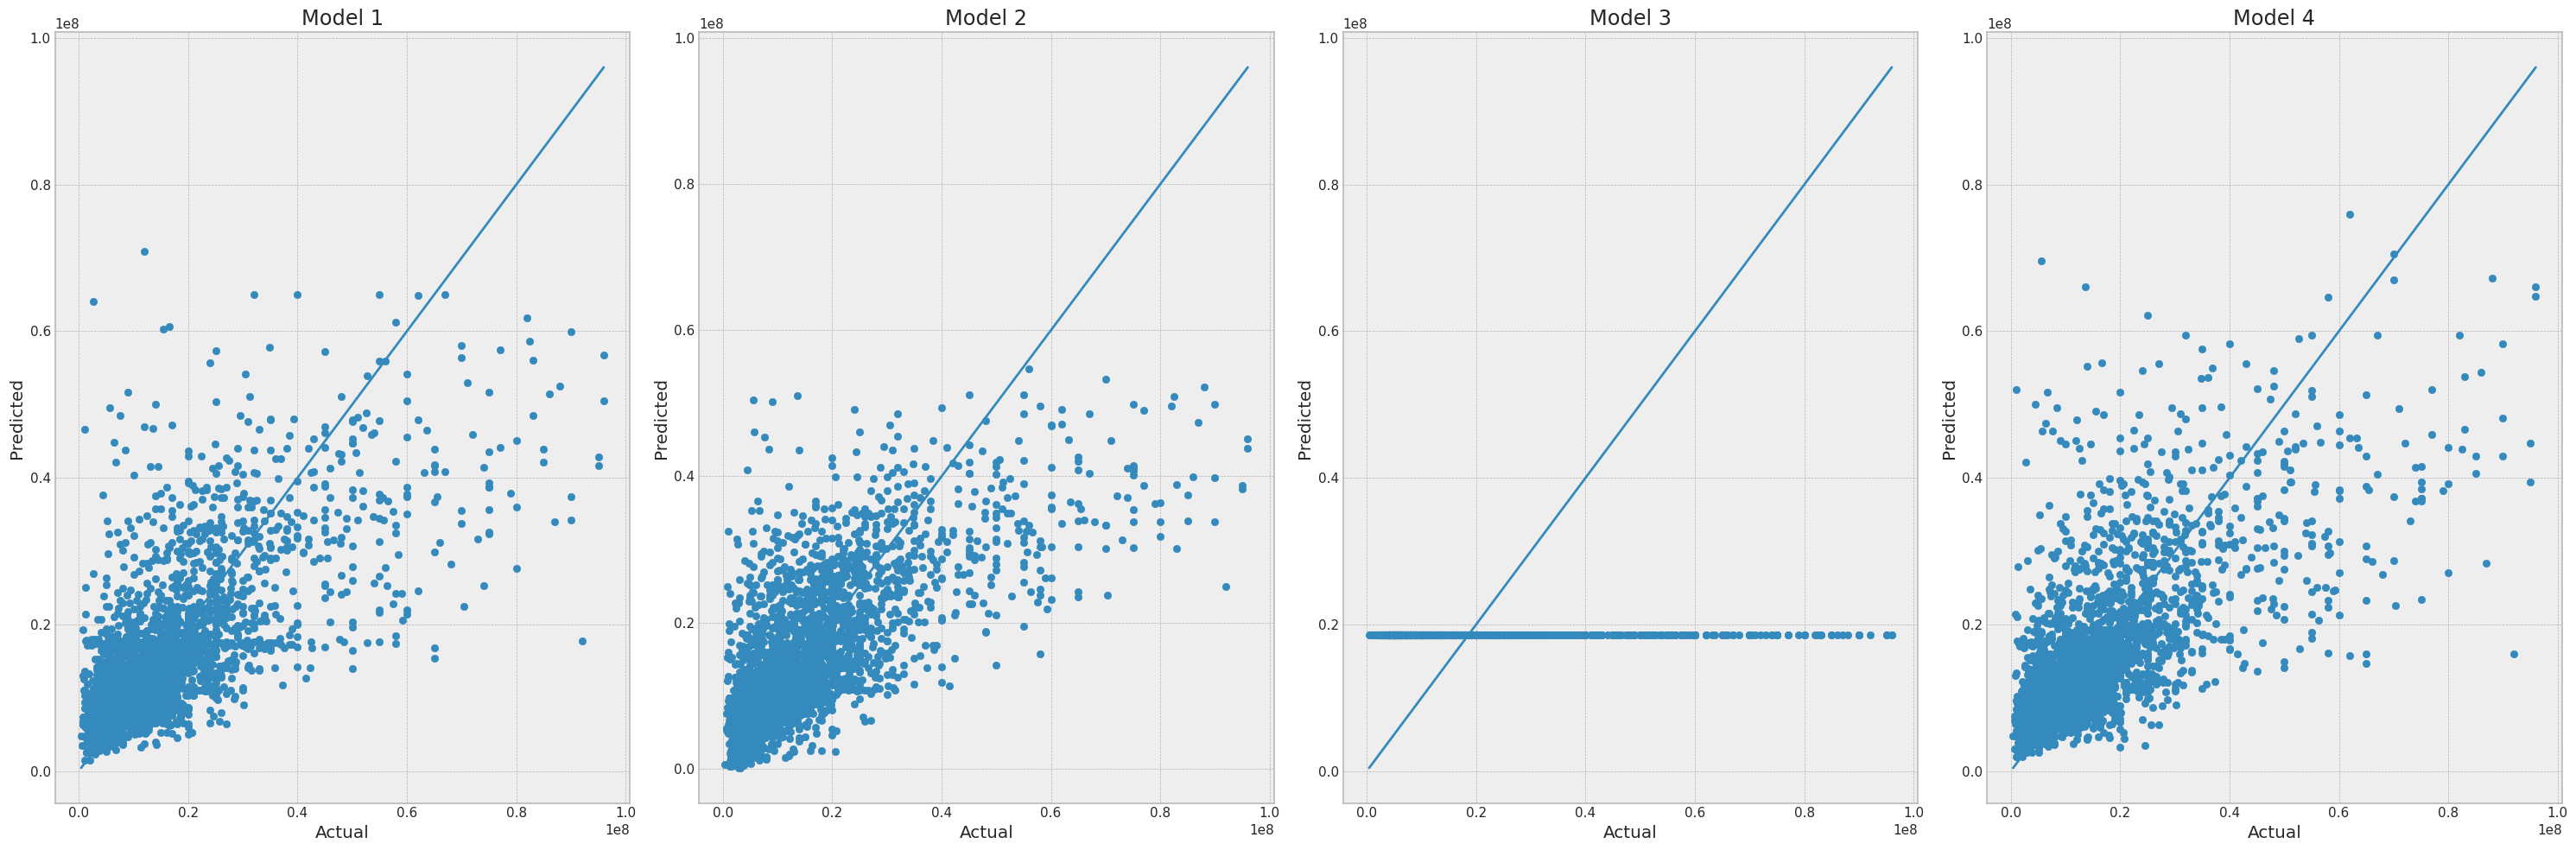

In [ ]:
models = {
    "RandomForest": RandomForestRegressor(max_depth=10,n_estimators=500),
    "LinearRegression": LinearRegression(),
    "SVR": SVR(max_iter=1000),
    "XGBoost": XGBRegressor(eval_metric='logloss',use_label_encoder=False),
}
plt.figure(figsize=(30, 10))
i=1
values={}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    values[f'{name}']={"RMSE:":root_mean_squared_error(y_test, y_pred),"R2:": r2_score(y_test, y_pred)}
    plt.subplot(1, len(models), i)
    plt.scatter(y_test, y_pred)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Model {i}")
    i += 1
plt.tight_layout()
plt.show()


In [ ]:
for user, info in values.items():
    for k, v in info.items():
        print(f"{user}_{k} = {v}")
    print('='*50)

RandomForest_RMSE: = 9393868.31003194
RandomForest_R2: = 0.5197457924298308
LinearRegression_RMSE: = 9406723.922446605
LinearRegression_R2: = 0.5184304266366019
SVR_RMSE: = 14107740.679882245
SVR_R2: = -0.08317138760401299
XGBoost_RMSE: = 9579744.559517948
XGBoost_R2: = 0.5005522039416439
